In [3]:
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import hist
# import hist.dask as hda
# import dask
# import coffea.processor as processor
# from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import vector

# NanoAODSchema.warn_missing_crossrefs = False

# IGNORE THE WARNING 

In [3]:
# Datasets:
#/BulkGravToWW_narrow_M-*_13TeV-madgraph/*NanoAODv7*/NANOAODSIM
#/RSGravToWWToWlepWhad_width0p1_M-*_TuneCUETP8M1_13TeV-madgraph-pythia8/*NanoAODv3*/NANOAODSIM


# When having a large number of files it is useful to put the list on a separate file.
# import json

# with open("semileptonic_notebooks/samples.json", 'r') as sample_file:
#     fileset = json.load(sample_file)

# for sample in fileset:
#     print(sample)

# For now we are only testing on a limited number of files so they are just listed here
# fileset = {
#     'BulkGravToWW': {
#         'files': {
#             'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv7/BulkGravToWW_narrow_M-1000_13TeV-madgraph/NANOAODSIM/PUMoriond17_Nano02Apr2020_102X_mcRun2_asymptotic_v8-v1/100000/D4404DCB-FBF8-C640-87B0-2DA1D5139083.root': "Events",
#         },
#         'metadata': {
#             'is_mc': 'Events',
#         },
#     },
#     'RSGravToWW': {
#         'files': {
#             'root://cmsxrootd.fnal.gov//store/mc/RunIISummer16NanoAODv3/RSGravToWWToWlepWhad_width0p1_M-1200_TuneCUETP8M1_13TeV-madgraph-pythia8/NANOAODSIM/PUMoriond17_94X_mcRun2_asymptotic_v3-v1/60000/4442437A-52BB-E811-A8DA-90E2BACC5EEC.root': "Events",
#           },
#         'metadata': {
#             'is_mc': 'Events',
#         },
#     }
# }

# Open the local ROOT file for BulkGraviton
file_bulk = uproot.open("BulkGravitonToWW_M-1000.root")
events_bulk = file_bulk["Events"].arrays([
    "GenPart_pdgId", "GenPart_genPartIdxMother",
    "GenPart_pt", "GenPart_eta", "GenPart_phi", "GenPart_mass"
], entry_stop=1000)

# Open the local ROOT file for RSGrav
file_rs = uproot.open("RSGravToWWToWlepWhad_M-1200.root")
events_rs = file_rs["Events"].arrays([
    "GenPart_pdgId", "GenPart_genPartIdxMother",
    "GenPart_pt", "GenPart_eta", "GenPart_phi", "GenPart_mass"
], entry_stop=1000)

In [71]:
# This step takes some time because it is loading the events
# test_dataset = 'BulkGravToWW'
# events = NanoEventsFactory.from_root(
#     fileset[test_dataset]['files'],
#     entry_stop = 1000, # this limit the number of events, good to experiment more quickly
#     metadata = fileset[test_dataset]['metadata'],
#     schemaclass = NanoAODSchema,
#     delayed=False,
# ).events()

test_dataset = "BulkGravToWW"
events = events_bulk

# test_dataset = "RSGravToWW"
# events = events_rs

In [6]:
# print(Lets get familiar with what is insiede an event of a NanoAOD file:)
# events.fields


# print(Now we want to learn about the particles in our events)

# print(type(events.GenPart))
# print(events.GenPart.fields)

print("Let's get familiar with what is inside an event of a file:")
print(events.fields)  # could also do ak.fields(events)

print("\nNow we want to learn about the particles in our events")

# Simulate the structure of GenPart using one of its arrays
print("Type of GenPart (from pdgId):", type(events["GenPart_pdgId"]))
print("Available GenPart fields:")
print([key for key in events.fields if key.startswith("GenPart_")])


Let's get familiar with what is inside an event of a file:
['GenPart_pdgId', 'GenPart_genPartIdxMother', 'GenPart_pt', 'GenPart_eta', 'GenPart_phi', 'GenPart_mass']

Now we want to learn about the particles in our events
Type of GenPart (from pdgId): <class 'awkward.highlevel.Array'>
Available GenPart fields:
['GenPart_pdgId', 'GenPart_genPartIdxMother', 'GenPart_pt', 'GenPart_eta', 'GenPart_phi', 'GenPart_mass']


### TASK 1: 
Understand the meaning of the GenPart fields that you should have printed. Some are more easy then others. For now you should make sure you understand 'eta', 'mass', 'phi', 'pt', 'genPartIdxMother', 'pdgId'

In [7]:
print("Example values from event 0:")
for field in ["GenPart_pdgId", "GenPart_genPartIdxMother", "GenPart_pt", "GenPart_eta", "GenPart_phi", "GenPart_mass"]:
    print(f"{field}: {events[field][0]}")

"""
GenPart_pdgId: Particle ID code (PDG): Tells you what particle it is.
GenPart_genPartIdxMother: Index of the mother particle: helps reconstruct decay chains
GenPart_pt: Transverse momentum (GeV): helps select particles with different energies.
GenPart_eta: Pseudprapiditiy: the angle between the beamline and the plane of pt
GenPart_phi: azimuthal angle: completing 3-dimentional information.
GenPart_mass: Invariant mass (GeV): helps identify particle type, resonance mass.
"""

Example values from event 0:
GenPart_pdgId: [21, 21, 39, 39, 22, 24, -24, 14, -13, ..., 11, -11, 22, 22, 22, 22, 11, -11]
GenPart_genPartIdxMother: [-1, -1, 0, 2, -1, 3, 3, 5, 5, 6, ..., 24, 30, 27, 27, 32, 32, 33, 35, 25, 25]
GenPart_pt: [0, 0, 5.68e-14, 284, 18.5, 460, ..., 26.2, 10.5, 32.8, 13.2, 0.0779, 0.00249]
GenPart_eta: [2.35e+04, -2.31e+04, 37.2, 0.646, -0.66, ..., -0.145, -0.114, 3.88, 3.7]
GenPart_phi: [0, 0, 1.57, -0.516, 3.12, 1.14, -1.47, ..., 2.49, 2.5, 2.52, 2.52, -2.75, 2.21]
GenPart_mass: [0, 0, 1e+03, 1e+03, 0, 80.8, 78.2, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### TASK 2: 
Can you select the W bosons? Can you print the value of the W boson mass? And plot?


W boson masses (first 10 entries):
[[80.75, 78.25], [79.0, 80.25], [80.0, 79.5], [80.75, 83.25], [76.0, 82.0], [78.75, 85.0], [80.5, 83.0], [82.75, 88.5], [79.25, 80.5], [79.75, 80.25]]


/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-numpy/1.24.3-a3a65cbc18c6a98e06451d4329e3ea47/lib/python3.9/site-packages/numpy/core/getlimits.py:518: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-numpy/1.24.3-a3a65cbc18c6a98e06451d4329e3ea47/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


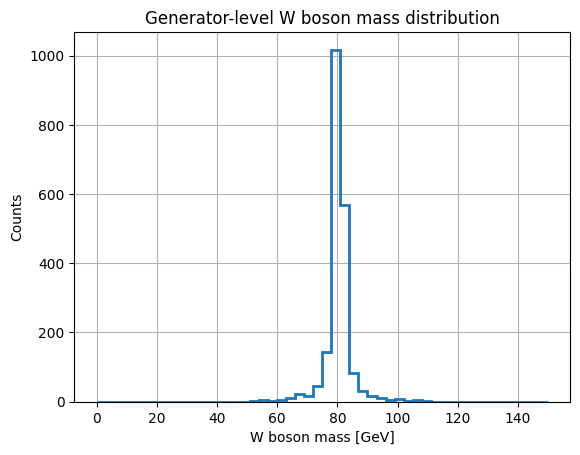

In [8]:
# Implement here your code

# Select W bosons at generator level and examine their mass distribution.

# 1. Select W bosons using PDG ID: +24 (W⁺), -24 (W⁻)
w_mask = abs(events["GenPart_pdgId"]) == 24
w_masses = events["GenPart_mass"][w_mask]

# 2. Print the first few W masses
print("W boson masses (first 10 entries):")
print(ak.to_list(w_masses[:10]))

# 3. Flatten the jagged array for histogramming
w_masses_flat = ak.flatten(w_masses)

# 4. Plot the mass distribution
plt.hist(w_masses_flat, bins=50, range=(0, 150), histtype='step', linewidth=2)
plt.xlabel("W boson mass [GeV]")
plt.ylabel("Counts")
plt.title("Generator-level W boson mass distribution")
plt.grid(True)
plt.show()

### TASK 3:

Plot also the other kinematic variables

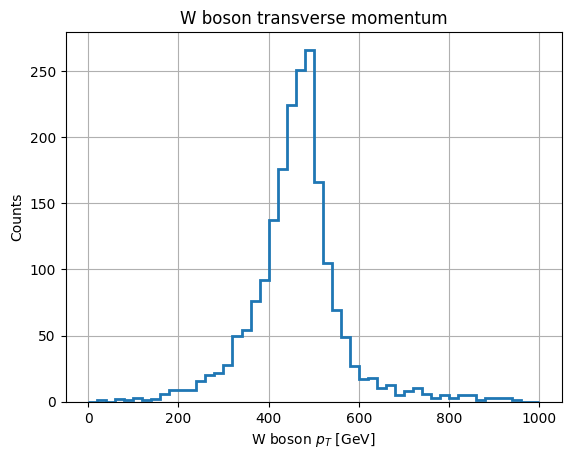

In [9]:
# Implement here your code

# Plot the transverse momentum (pt) of generator-level W bosons

w_pt = events["GenPart_pt"][w_mask]
w_pt_flat = ak.flatten(w_pt)

plt.hist(w_pt_flat, bins=50, range=(0, 1000), histtype='step', linewidth=2)
plt.xlabel("W boson $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("W boson transverse momentum")
plt.grid(True)
plt.show()

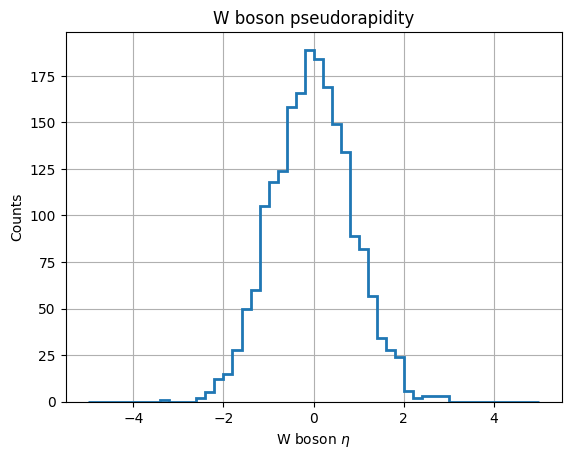

In [10]:
# Plot the pseudorapidity (eta) of generator-level W bosons

w_eta = events["GenPart_eta"][w_mask]
w_eta_flat = ak.flatten(w_eta)

plt.hist(w_eta_flat, bins=50, range=(-5, 5), histtype='step', linewidth=2)
plt.xlabel("W boson $\eta$")
plt.ylabel("Counts")
plt.title("W boson pseudorapidity")
plt.grid(True)
plt.show()

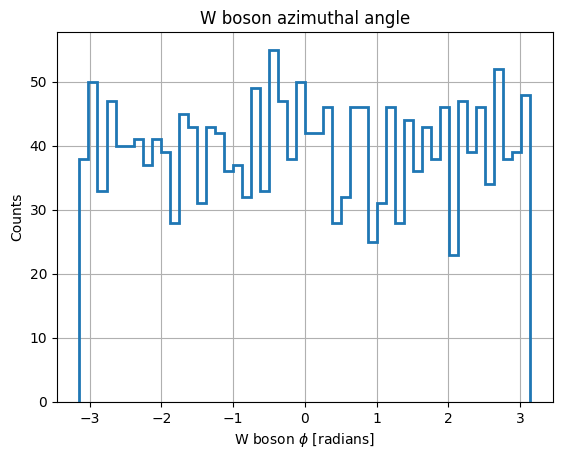

In [11]:
# Plot the azimuthal angle (phi) of generator-level W bosons

w_phi = events["GenPart_phi"][w_mask]
w_phi_flat = ak.flatten(w_phi)

plt.hist(w_phi_flat, bins=50, range=(-np.pi, np.pi), histtype='step', linewidth=2)
plt.xlabel("W boson $\phi$ [radians]")
plt.ylabel("Counts")
plt.title("W boson azimuthal angle")
plt.grid(True)
plt.show()

### TASK 4: 
Now identify the quarks coming from the W bosons and plot their kinematic variables


In [ ]:
# Implement here your code 
# This starts to get more complicated! Take your time to think!

"""
W-bosons decay to two quarks (u,d,s,c types) with pdgId values
    --> u: 2, c: 4
    --> d: 1, s: 3 and also b:5 but that usually comes from top decay.
Identify them by looking for:
    --> particles with |pdgId| between 1 and 6
    --> mother index point to a W boson (|pdgId| == 24)
"""

In [25]:
# Select quarks coming from W boson decays

# # Unpack needed branches
# pdgId     = events["GenPart_pdgId"]
# motherIdx = events["GenPart_genPartIdxMother"]
# pt        = events["GenPart_pt"]
# eta       = events["GenPart_eta"]
# phi       = events["GenPart_phi"]
# mass      = events["GenPart_mass"]

# # Step 1: Identify W bosons in each event
# is_w = abs(pdgId) == 24
# w_indices = ak.local_index(pdgId)[is_w]

# # Step 2: Identify quarks (|pdgId| in 1–6) that have W bosons as mothers
# is_quark = (abs(pdgId) >= 1) & (abs(pdgId) <= 6)

# # Use awkward indexing to select quarks whose mothers are W bosons
# # Create a mask: is the mother of this particle a W boson?
# mother_is_w = is_w[motherIdx]  # this maps mother index → W check

# # Combine all three conditions:
# # 1. It's a quark
# # 2. It has a mother (motherIdx != -1)
# # 3. Its mother is a W boson
# quark_from_w_mask = is_quark & (motherIdx != -1) & mother_is_w

# # Apply the mask to extract kinematic variables
# quark_pt = pt[quark_from_w_mask]
# quark_eta = eta[quark_from_w_mask]
# quark_phi = phi[quark_from_w_mask]
# quark_mass = mass[quark_from_w_mask]

# Unpack GenPart fields
pdgId = events["GenPart_pdgId"]
motherIdx = events["GenPart_genPartIdxMother"]
pt = events["GenPart_pt"]
eta = events["GenPart_eta"]
phi = events["GenPart_phi"]
mass = events["GenPart_mass"]

# Step 1: Identify quarks (|pdgId| ∈ [1,6]) and valid mothers
is_quark = (abs(pdgId) >= 1) & (abs(pdgId) <= 6)
has_mother = motherIdx != -1

# Step 2: Get pdgId of the mother particle using awkward indexing
mother_pdgId = pdgId[motherIdx]

# Step 3: Identify if mother is a W boson (±24)
mother_is_w = abs(mother_pdgId) == 24

# Step 4: Final mask — quarks from W bosons
quark_from_w_mask = is_quark & has_mother & mother_is_w

# Step 5: Apply mask to extract kinematic variables
quark_pt   = pt[quark_from_w_mask]
quark_eta  = eta[quark_from_w_mask]
quark_phi  = phi[quark_from_w_mask]
quark_mass = mass[quark_from_w_mask]

In [26]:
print("Number of quarks from W decays:", ak.sum(ak.num(quark_pt)))

Number of quarks from W decays: 2670


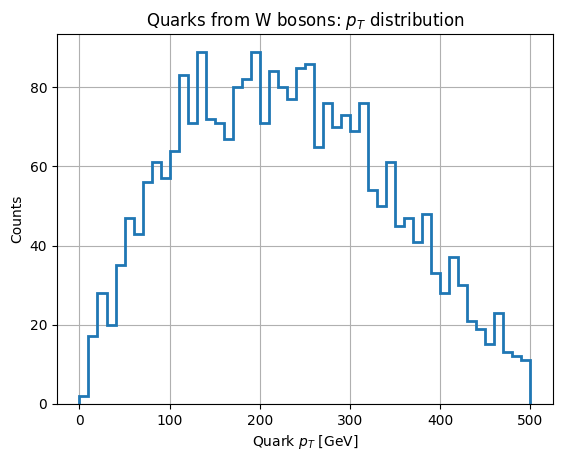

In [27]:
quark_pt_flat = ak.flatten(quark_pt)

plt.hist(quark_pt_flat, bins=50, range=(0, 500), histtype='step', linewidth=2)
plt.xlabel("Quark $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Quarks from W bosons: $p_T$ distribution")
plt.grid(True)
plt.show()

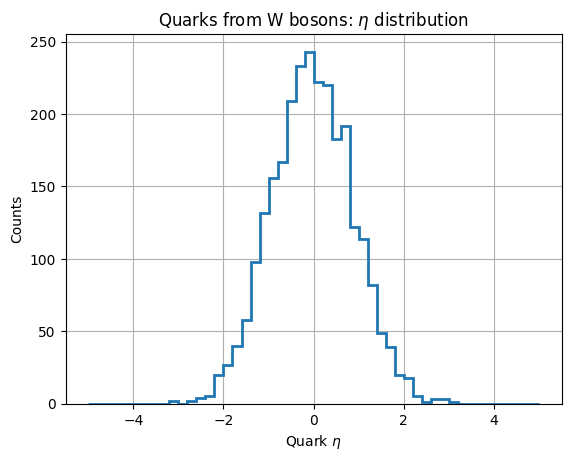

In [28]:
quark_eta_flat = ak.flatten(quark_eta)

plt.hist(quark_eta_flat, bins=50, range=(-5, 5), histtype='step', linewidth=2)
plt.xlabel("Quark $\eta$")
plt.ylabel("Counts")
plt.title("Quarks from W bosons: $\eta$ distribution")
plt.grid(True)
plt.show()

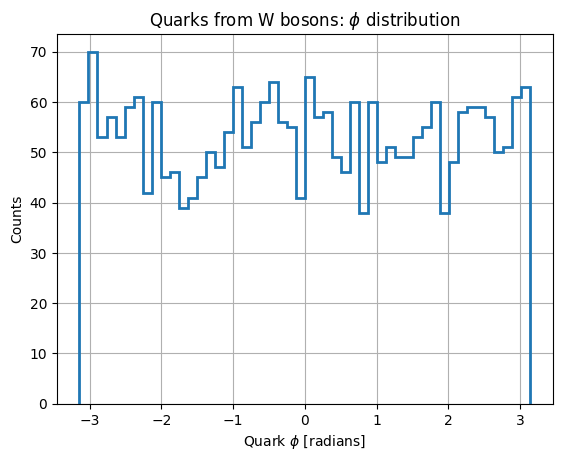

In [29]:
quark_phi_flat = ak.flatten(quark_phi)

plt.hist(quark_phi_flat, bins=50, range=(-np.pi, np.pi), histtype='step', linewidth=2)
plt.xlabel("Quark $\phi$ [radians]")
plt.ylabel("Counts")
plt.title("Quarks from W bosons: $\phi$ distribution")
plt.grid(True)
plt.show()

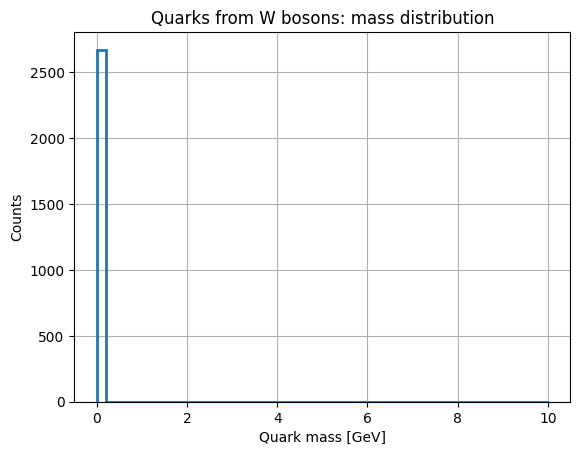

In [30]:
quark_mass_flat = ak.flatten(quark_mass)

plt.hist(quark_mass_flat, bins=50, range=(0, 10), histtype='step', linewidth=2)
plt.xlabel("Quark mass [GeV]")
plt.ylabel("Counts")
plt.title("Quarks from W bosons: mass distribution")
plt.grid(True)
plt.show()

In [36]:
print("Example quark masses (first 10):", ak.to_list(ak.flatten(quark_mass[:10])))
#whats happening here? theyre all zero

# if all masses are zero, am i selecting the right quarks?
print("PDG IDs of quarks from W (first 10):", ak.to_list(ak.flatten(pdgId[quark_from_w_mask][:10])))
#the PDG IDs are in the range 1–6 or -1 to -6.
# I'm seeing reasonable quark IDs (e.g., ±1, ±2, ±3, ±4), that's good — means selection is working.

#double-checking if GenPart_mass globally contains any non-zero values at all.
# If everything is zero, then the problem is upstream: the NanoAOD doesn't have quark masses?
# print("Unique masses in GenPart_mass:", np.unique(ak.to_numpy(ak.flatten(events["GenPart_mass"]))))

#Which types of particles are assigned non-zero masses?
#extract the PDG IDs of only those particles whose GenPart_mass > 0
nonzero_mass_mask = events["GenPart_mass"] > 0
nonzero_mass_ids = pdgId[nonzero_mass_mask]

#Are any quarks assigned mass at all? Or is it just composite hadrons, bosons, etc.?
print("Unique PDG IDs with non-zero mass in GenPart:", ak.to_list(np.unique(ak.to_numpy(ak.flatten(nonzero_mass_ids)))))
# This confirms that the NanoAOD sample simply does not assign non-zero mass to fundamental quarks, which makes sense?

Example quark masses (first 10): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
PDG IDs of quarks from W (first 10): [2, -1, 2, -1, 1, -2, 2, -1, 1, -2, 2, -1, -3, 4, 1, -2, -3, 4, 3, -4]
Unique PDG IDs with non-zero mass in GenPart: [-5132, -5122, -5114, -5112, -4334, -4332, -4312, -4232, -4224, -4222, -4214, -4212, -4132, -4122, -4114, -4112, -3212, -531, -523, -521, -513, -511, -433, -431, -423, -413, -321, -311, -24, 24, 39, 113, 130, 221, 223, 310, 311, 313, 321, 331, 333, 413, 415, 423, 425, 431, 433, 441, 443, 445, 511, 513, 521, 523, 531, 533, 541, 543, 1103, 2101, 2103, 2203, 3212, 4112, 4114, 4122, 4132, 4212, 4214, 4222, 4224, 4232, 4322, 4324, 5114, 5122, 5132, 5232]


#### Bonus task:

Are there many quarks not coming from the Ws? Would your answer be different if you would be using Vector Boson Scattering samples? Remind me about it at some point and we may give it a go :)

## Polarization variable cos theta

To calculate this variable we are putting together some of the things you have been working on before. Two functions have already been implemented for you. Read them below and try to understand what they do. Add all printouts that you need. Also printing the type of the variables is useful. Or running on a small number of events to explore them in depth.

In [50]:
# This code was written by David https://github.com/wbuitrago/Scripts_HadronicVBS/blob/main/Costheta.py
def get_w_decay_quark_pairs_gen(events):
    """
    Extraction of pairs of quarks coming from a W boson at generator level.
    Returns a list of [q1_vec, q2_vec] where each is a vector.Momentum4D object.
    """

    if events is None or len(events) == 0:
        return []

    # Use awkward-compatible field access
    pdgId   = events["GenPart_pdgId"]
    mothers = events["GenPart_genPartIdxMother"]
    pt      = events["GenPart_pt"]
    eta     = events["GenPart_eta"]
    phi     = events["GenPart_phi"]
    mass    = events["GenPart_mass"]

    all_quark_pairs_vectors = []

    print(f"[INFO] Processing events to find W → qq'. Total events: {len(events)}")

    num_w_decay_to_quarks = 0

    for i in range(len(events)): 
        event_pdgId = pdgId[i]
        event_mothers = mothers[i]

        # Print a few entries to explore structure
        if i < 2:
            print(f"\n[DEBUG] Event {i}")
            print("  PDG IDs:", ak.to_list(event_pdgId))
            print("  Mother indices:", ak.to_list(event_mothers))

        # Step 1: Find W bosons in this event
        w_indices_in_event = ak.local_index(event_pdgId)[abs(event_pdgId) == 24]

        if i < 2:
            print("  W boson indices in event:", ak.to_list(w_indices_in_event))

        for w_idx in w_indices_in_event:
            # Step 2: Find daughters of this W that are quarks
            daughter_indices = ak.local_index(event_pdgId)[
                (event_mothers == w_idx) & (abs(event_pdgId) >= 1) & (abs(event_pdgId) <= 6)
            ]

            if i < 2:
                print(f"    W index {w_idx} has daughter quarks at indices:", ak.to_list(daughter_indices))

            # Step 3: Only keep W → qq′ if it has exactly 2 quark daughters
            if len(daughter_indices) == 2:
                num_w_decay_to_quarks += 1

                # Extract the two quark kinematic properties
                q1_data = {
                    "pt": pt[i][daughter_indices[0]],
                    "eta": eta[i][daughter_indices[0]],
                    "phi": phi[i][daughter_indices[0]],
                    "mass": mass[i][daughter_indices[0]],
                }
                q2_data = {
                    "pt": pt[i][daughter_indices[1]],
                    "eta": eta[i][daughter_indices[1]],
                    "phi": phi[i][daughter_indices[1]],
                    "mass": mass[i][daughter_indices[1]],
                }

                if i < 2:
                    print(f"    q1: {q1_data}")
                    print(f"    q2: {q2_data}")

                # Build 4-vectors
                q1_vec = vector.obj(pt=q1_data["pt"], eta=q1_data["eta"], phi=q1_data["phi"], mass=q1_data["mass"])
                q2_vec = vector.obj(pt=q2_data["pt"], eta=q2_data["eta"], phi=q2_data["phi"], mass=q2_data["mass"])

                all_quark_pairs_vectors.append([q1_vec, q2_vec])

    print(f"[INFO] Found {len(all_quark_pairs_vectors)} W → qq′ quark pairs across {len(events)} events.")
    print(f"[INFO] Number of accepted W decays: {num_w_decay_to_quarks}")

    return all_quark_pairs_vectors

In [72]:
w_decay_quark_pairs_gen = get_w_decay_quark_pairs_gen(events)

[INFO] Processing events to find W → qq'. Total events: 1000

[DEBUG] Event 0
  PDG IDs: [21, 21, 39, 39, 22, 24, -24, 14, -13, 11, -12, -12, 11, 22, 22, -423, 2, 21, 21, 21, 21, -2, 221, 411, -413, 2, -2, 2, 21, -3, 111, 411, 111, 111, -421, 111, 22, 22, -411, 22, 11, -11, 22, 22, 22, 22, 11, -11]
  Mother indices: [-1, -1, 0, 2, -1, 3, 3, 5, 5, 6, 6, 10, 9, 9, 9, -1, -1, -1, -1, -1, -1, -1, 16, -1, -1, -1, -1, -1, -1, -1, 27, -1, 16, 16, 15, 16, 22, 22, 24, 30, 27, 27, 32, 32, 33, 35, 25, 25]
  W boson indices in event: [5, 6]
    W index 5 has daughter quarks at indices: []
    W index 6 has daughter quarks at indices: []

[DEBUG] Event 1
  PDG IDs: [21, 21, 39, 39, 24, -24, 2, -1, -16, 15, 21, 21, 2, 21, 21, 21, -1, 221, 1, 21, 2101, 16, 111, -211, -211, 211, 22, 11, -11, 22, 22, 11, -11, 11, -11]
  Mother indices: [-1, -1, 0, 2, 3, 3, 4, 4, 5, 5, -1, -1, 6, 6, 7, 7, 7, 7, -1, -1, -1, 9, 9, 9, 9, 9, 17, 18, 18, 22, 22, 10, 10, 18, 18]
  W boson indices in event: [4, 5]
    W index 

In [52]:
# This code was written by David https://github.com/wbuitrago/Scripts_HadronicVBS/blob/main/Costheta.py
def calculate_cos_theta_star_gen(quark_pairs_vectors):
    """
    Compute cos(theta*) for each pair of quarks from W decay.
    theta* is the angle between the quark direction (in the W rest frame)
    and the W direction in the lab frame.
    """
    cos_theta_stars = []

    if not quark_pairs_vectors:
        print("[WARN] No quark pairs found. Skipping cos(theta*) calculation.")
        return np.array([])

    print(f"[INFO] Calculating cos(theta*) for {len(quark_pairs_vectors)} W → qq′ pairs...")

    for q1, q2 in quark_pairs_vectors:
        # Reconstruct W boson 4-momentum
        w_lab = q1 + q2

        # Sanity check: skip unphysical or zero-energy Ws
        if w_lab.mass < 1e-3 or w_lab.E <= 1e-6:
            continue

        # Boost q1 into W rest frame
        beta3 = w_lab.to_beta3()
        q1_in_w_rest = q1.boost_beta3(-beta3)

        # Define direction of W in the lab (z′ axis in helicity frame)
        w_dir_lab = w_lab.to_beta3()
        q1_dir_rest = q1_in_w_rest.to_beta3()

        # Sanity checks
        if w_dir_lab.mag < 1e-6 or q1_dir_rest.mag < 1e-6:
            continue

        # Compute cos(theta*)
        cos_theta = q1_dir_rest.unit().dot(w_dir_lab.unit())
        cos_theta_stars.append(cos_theta)

    print(f"[INFO] Computed {len(cos_theta_stars)} values of cos(theta*) successfully.")
    return np.array(cos_theta_stars)

In [73]:
cos_theta_star_gen = calculate_cos_theta_star_gen(w_decay_quark_pairs_gen)
# print(cos_theta_star_gen)

[INFO] Calculating cos(theta*) for 1335 W → qq′ pairs...
[INFO] Computed 1335 values of cos(theta*) successfully.


In [74]:
cos_theta_bulk = cos_theta_star_gen

In [70]:
cos_theta_rs = cos_theta_star_gen

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f44e8fd8c10>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

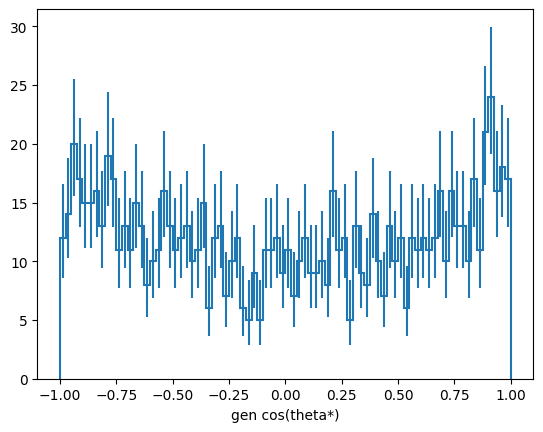

In [47]:
# 1. Create a histogram with category axis (dataset) and a regular axis for cos(theta*)
gen_cos_theta_star_hist = hist.Hist(
    hist.axis.StrCategory(name='dataset', label="BG", categories=[], growth=True),
    hist.axis.Regular(name='gen_AK8_cos_theta_star', label='gen cos(theta*)', bins=80, start=-1, stop=1))

# 2. Fill the histogram with values from the current dataset
gen_cos_theta_star_hist.fill(
    dataset=test_dataset,
    gen_AK8_cos_theta_star=cos_theta_star_gen)

# 3. Plot the distribution
gen_cos_theta_star_hist.plot1d()

### TASK 5:

Can you plot the variables above also for the RSGraviton? The easiest way is to change the `test_dataset` above. Are there differences?

### TASK 6:
To better compare them, can you plot them on the same figure? At least the `cos_theta_star_gen`

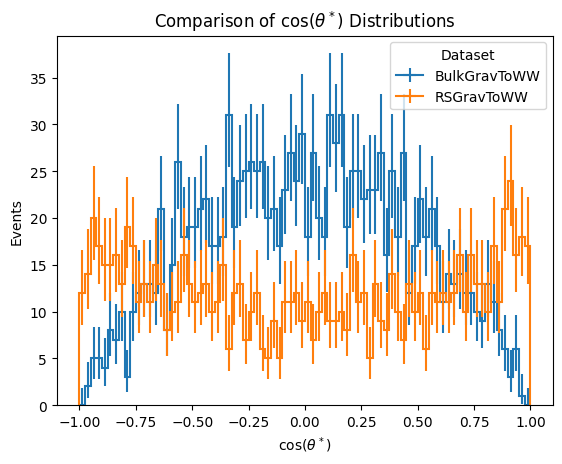

In [78]:
import matplotlib.pyplot as plt

# Create a histogram with dataset as categorical axis
cos_theta_hist = hist.Hist(
    hist.axis.StrCategory(name='dataset', label="Dataset", categories=[], growth=True),
    hist.axis.Regular(name='cos_theta_star', label='cos($\\theta^*$)', bins=80, start=-1, stop=1)
)

# Fill histogram for both datasets
cos_theta_hist.fill(dataset="BulkGravToWW", cos_theta_star=cos_theta_bulk)
cos_theta_hist.fill(dataset="RSGravToWW",   cos_theta_star=cos_theta_rs)

# Plot
fig, ax = plt.subplots()
cos_theta_hist.plot1d(ax=ax)

# Add legend
ax.legend(title="Dataset")
plt.title("Comparison of cos($\\theta^*$) Distributions")
plt.xlabel("cos($\\theta^*$)")
plt.ylabel("Events")

plt.show()

### TASK 7: 

When you are happy with the result, go back to the beginning and add more files with different resonance mass (Let me know when you are here! Not sure it is easy for you to get the list of files!!)

## What we see in our detectors is not the generated particles but it is convolved with their interactions with the detectors or more deacys. For instance Jets instead if Quarks.

Below are two functions implemented for you that match the generated particles with the jets in the event.
1) Do you know what a jet is? I can provide more material and explanation to learn
2) Read the functions and try to understand what they do. Add all printouts that you need. Also printing the type of the variables is useful. Or running on a small number of events to explore them in depth.

##### What Are Jets?

- **Quarks and gluons** cannot exist freely due to color confinement; instead, they hadronize into collimated sprays of particles called **jets**.

- A **jet** is a collection of particles (mostly hadrons) resulting from the fragmentation and hadronization of a high-energy parton (quark or gluon).

- In detectors (like CMS), jets are reconstructed from calorimeter deposits or particle-flow objects using clustering algorithms like **anti-\(k_T\)**.

- Jets are our best **experimental proxy** for quarks and gluons. While we study quarks at the generator level, jets are what we actually measure.

In [22]:
# Load BulkGraviton sample
file_bulk = uproot.open("BulkGravitonToWW_M-1000.root")
events_bulk = file_bulk["Events"].arrays(
    filter_name=lambda name: (
        name.startswith("GenPart_") or 
        name.startswith("GenJetAK8_") or 
        name.startswith("FatJet_") or
        name.startswith("SubJet_")
    ),
    entry_stop=1000)

# Load RSGraviton sample
file_rs = uproot.open("RSGravToWWToWlepWhad_M-1200.root")
events_rs = file_rs["Events"].arrays(
    filter_name=lambda name: (
        name.startswith("GenPart_") or 
        name.startswith("GenJetAK8_") or 
        name.startswith("FatJet_") or
        name.startswith("SubJet_")
    ),
    entry_stop=1000)

In [23]:
test_dataset = "BulkGravToWW"
events = events_bulk

In [7]:
# This code was written by David https://github.com/wbuitrago/Scripts_HadronicVBS/blob/main/Costheta.py
def get_w_quark_pairs(events):
    """
    Matches W bosons to their quark daughters at generator level using GenPart information.
    Returns a dictionary: (event_index, w_boson_index) → [quark1_index, quark2_index]
    """
    pdgId = events["GenPart_pdgId"]
    mothers = events["GenPart_genPartIdxMother"]

    is_w = abs(pdgId) == 24
    is_quark = (abs(pdgId) <= 6)

    # Index arrays for W bosons and quarks
    w_indices = ak.local_index(pdgId)[is_w]
    quark_indices = ak.local_index(pdgId)[is_quark]
    quark_parents = mothers[is_quark]

    w_quark_map = {}

    for evt_idx in range(len(pdgId)):
        event_w_indices = w_indices[evt_idx]
        event_quark_indices = quark_indices[evt_idx]
        event_quark_parents = quark_parents[evt_idx]

        for w_idx_in_event in event_w_indices:
            # Match quarks whose parent is the W boson
            daughter_quarks_indices = event_quark_indices[event_quark_parents == w_idx_in_event]

            if len(daughter_quarks_indices) == 2:
                w_quark_map[(evt_idx, int(w_idx_in_event))] = ak.to_list(daughter_quarks_indices)

    print(f"[INFO] Matched {len(w_quark_map)} W bosons to quark pairs.")
    return w_quark_map

In [8]:
w_quark_map = get_w_quark_pairs(events)

[INFO] Matched 1335 W bosons to quark pairs.


In [9]:
# This code was written by David https://github.com/wbuitrago/Scripts_HadronicVBS/blob/main/Costheta.py
# Matching GenJetAK8 and FatJet with the quark pairs coming from the W decay
def match_w_to_fatjets(events, w_quark_map):
    """
    For each W → qq′ decay, this function attempts to find a FatJet that matches
    the generator-level quarks based on proximity to GenJetAK8 jets (ΔR < 0.8).
    """
    # Step 0: Create an empty list of matched fatjets for each event
    matched_fatjets_per_event = [[] for _ in range(len(events))]

    # Step 1: Define GenJetAK8 as 4-vectors
    genjets = vector.zip({
        "pt": events["GenJetAK8_pt"],
        "eta": events["GenJetAK8_eta"],
        "phi": events["GenJetAK8_phi"],
        "mass": events["GenJetAK8_mass"],
    })

    # Step 2: Collect FatJet info (not using vector here since we don’t need full 4-vector ops)
    fatjets = ak.zip({
        "pt": events["FatJet_pt"],
        "eta": events["FatJet_eta"],
        "phi": events["FatJet_phi"],
        "mass": events["FatJet_mass"],
        "msoftdrop": events["FatJet_msoftdrop"],
        "tau1": events["FatJet_tau1"],
        "tau2": events["FatJet_tau2"],
        "genJetIdx": events["FatJet_genJetAK8Idx"],
        "subJetIdx1": events["FatJet_subJetIdx1"],
        "subJetIdx2": events["FatJet_subJetIdx2"],
    })

    # Step 3: Define GenParticles as 4-vectors
    genparts = vector.zip({
        "pt": events["GenPart_pt"],
        "eta": events["GenPart_eta"],
        "phi": events["GenPart_phi"],
        "mass": events["GenPart_mass"],
    })

    print("[INFO] Starting matching of W decay quarks to GenJetAK8 and FatJets...")

    # Step 4: Loop over each (event_idx, W_idx) → [q1_idx, q2_idx] in the map
    for (evt_idx, w_gen_idx), quark_gen_indices in w_quark_map.items():
        q1_idx, q2_idx = quark_gen_indices
        q1 = genparts[evt_idx][q1_idx]
        q2 = genparts[evt_idx][q2_idx]

        print(f"\n[Event {evt_idx}] Matching W boson (GenIdx={w_gen_idx}) with quark pair (q1={q1_idx}, q2={q2_idx})")

        # Step 5: Loop over GenJetAK8s in the event
        for gj_local_idx, gj in enumerate(genjets[evt_idx]):
            dR1 = gj.deltaR(q1)
            dR2 = gj.deltaR(q2)

            if dR1 < 0.8 and dR2 < 0.8:
                print(f"  → Found GenJetAK8 (index={gj_local_idx}) matching both quarks with ΔR = ({dR1:.2f}, {dR2:.2f})")

                # Step 6: Match to the corresponding FatJet using genJetIdx
                fj_genJetIdx = events["FatJet_genJetAK8Idx"][evt_idx]
                matching_fatjet_mask = fj_genJetIdx == gj_local_idx
                matched_fjs = fatjets[evt_idx][matching_fatjet_mask]

                if len(matched_fjs) > 0:
                    matched_fatjets_per_event[evt_idx].append(matched_fjs[0])
                    print(f"    → Matched FatJet found with pT = {matched_fjs[0].pt:.2f}")
                    break  # One matched FatJet per W decay

    print("[INFO] Matching complete.\n")
    return ak.Array(matched_fatjets_per_event)

In [10]:
# define matched_fatjets
matched_fatjets = match_w_to_fatjets(events, w_quark_map)

[INFO] Starting matching of W decay quarks to GenJetAK8 and FatJets...

[Event 1] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.43, 0.09)
    → Matched FatJet found with pT = 468.25

[Event 3] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.24, 0.14)
    → Matched FatJet found with pT = 471.25

[Event 3] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.11, 0.20)
    → Matched FatJet found with pT = 606.50

[Event 4] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.08, 0.34)
    → Matched FatJet found with pT = 490.75

[Event 5] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.17, 0.14)
    → Matched FatJet found with pT = 517.50

  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.08, 0.18)
    → Matched FatJet found with pT = 667.50

[Event 62] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.49, 0.07)
    → Matched FatJet found with pT = 441.75

[Event 62] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=2) matching both quarks with ΔR = (0.51, 0.07)
    → Matched FatJet found with pT = 410.00

[Event 63] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.29, 0.08)
    → Matched FatJet found with pT = 580.00

[Event 63] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.19, 0.15)
    → Matched FatJet found with pT = 441.50

[Event 64] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.1


[Event 106] Matching W boson (GenIdx=5) with quark pair (q1=11, q2=12)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.39, 0.10)
    → Matched FatJet found with pT = 442.75

[Event 107] Matching W boson (GenIdx=5) with quark pair (q1=11, q2=12)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.27, 0.14)
    → Matched FatJet found with pT = 414.00

[Event 108] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.55, 0.40)
    → Matched FatJet found with pT = 565.00

[Event 111] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.14, 0.30)
    → Matched FatJet found with pT = 486.50

[Event 111] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.19, 0.11)
    → Matched FatJet found with pT = 587.50

[Event 112] Matching W boson (GenIdx=4) with quark pair

  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.05, 0.52)
    → Matched FatJet found with pT = 521.00

[Event 147] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.05, 0.46)
    → Matched FatJet found with pT = 497.75

[Event 151] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.25, 0.10)
    → Matched FatJet found with pT = 494.75

[Event 151] Matching W boson (GenIdx=5) with quark pair (q1=9, q2=10)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.13, 0.18)
    → Matched FatJet found with pT = 507.75

[Event 152] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.35, 0.05)
    → Matched FatJet found with pT = 594.00

[Event 152] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR 

  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.14, 0.25)
    → Matched FatJet found with pT = 436.00

[Event 192] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.03, 0.47)
    → Matched FatJet found with pT = 458.75

[Event 192] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.14, 0.27)
    → Matched FatJet found with pT = 449.25

[Event 193] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.11, 0.24)
    → Matched FatJet found with pT = 533.00

[Event 193] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.16, 0.14)
    → Matched FatJet found with pT = 474.75

[Event 194] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR =

...

    → Matched FatJet found with pT = 372.00

[Event 838] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.27, 0.17)
    → Matched FatJet found with pT = 380.00

[Event 839] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.03, 0.75)
    → Matched FatJet found with pT = 479.75

[Event 840] Matching W boson (GenIdx=6) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.39, 0.59)
    → Matched FatJet found with pT = 993.50

[Event 841] Matching W boson (GenIdx=6) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.09, 0.13)
    → Matched FatJet found with pT = 741.50

[Event 842] Matching W boson (GenIdx=6) with quark pair (q1=9, q2=10)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.24, 0.26)
    → Matched FatJet found with pT = 356.25

[Event 843] Ma

    → Matched FatJet found with pT = 507.50

[Event 878] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.07, 0.22)
    → Matched FatJet found with pT = 586.50

[Event 878] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.08, 0.55)
    → Matched FatJet found with pT = 427.75

[Event 880] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=2) matching both quarks with ΔR = (0.45, 0.34)
    → Matched FatJet found with pT = 223.62

[Event 880] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.05, 0.10)
    → Matched FatJet found with pT = 1221.00

[Event 881] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.10, 0.32)
    → Matched FatJet found with pT = 448.25

[Event 881] Ma

  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.13, 0.21)
    → Matched FatJet found with pT = 526.50

[Event 913] Matching W boson (GenIdx=7) with quark pair (q1=10, q2=11)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.26, 0.12)
    → Matched FatJet found with pT = 460.75

[Event 914] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.16, 0.18)
    → Matched FatJet found with pT = 426.75

[Event 914] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.09, 0.37)
    → Matched FatJet found with pT = 469.25

[Event 915] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.12, 0.25)
    → Matched FatJet found with pT = 483.75

[Event 916] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR

  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.34, 0.12)
    → Matched FatJet found with pT = 348.50

[Event 951] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.16, 0.20)
    → Matched FatJet found with pT = 511.75

[Event 953] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.16, 0.19)
    → Matched FatJet found with pT = 394.00

[Event 954] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.23, 0.18)
    → Matched FatJet found with pT = 465.50

[Event 954] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.25, 0.10)
    → Matched FatJet found with pT = 518.50

[Event 955] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR =

  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.19, 0.18)
    → Matched FatJet found with pT = 532.00

[Event 996] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.09, 0.34)
    → Matched FatJet found with pT = 523.00

[Event 997] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)

[Event 997] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)

[Event 998] Matching W boson (GenIdx=4) with quark pair (q1=6, q2=7)
  → Found GenJetAK8 (index=0) matching both quarks with ΔR = (0.29, 0.11)
    → Matched FatJet found with pT = 489.25

[Event 998] Matching W boson (GenIdx=5) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.24, 0.11)
    → Matched FatJet found with pT = 474.75

[Event 999] Matching W boson (GenIdx=6) with quark pair (q1=8, q2=9)
  → Found GenJetAK8 (index=1) matching both quarks with ΔR = (0.08, 0.41)
    → Matched FatJet found with pT

### TASK 8:

Plot on the same plot
1) the mass of the generated Ws
2) The mass of GenJetAK8
3) The mass of GenJetAK8 coming from a W (you need to write a function similar to the one above)
4) the mass of the FatJets
5) the mass of the FatJets coming from a W

Do you understand the plot?

#### Tip: you can run on only one file or with very few events when debugging your code

/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-numpy/1.24.3-a3a65cbc18c6a98e06451d4329e3ea47/lib/python3.9/site-packages/numpy/core/getlimits.py:518: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-numpy/1.24.3-a3a65cbc18c6a98e06451d4329e3ea47/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


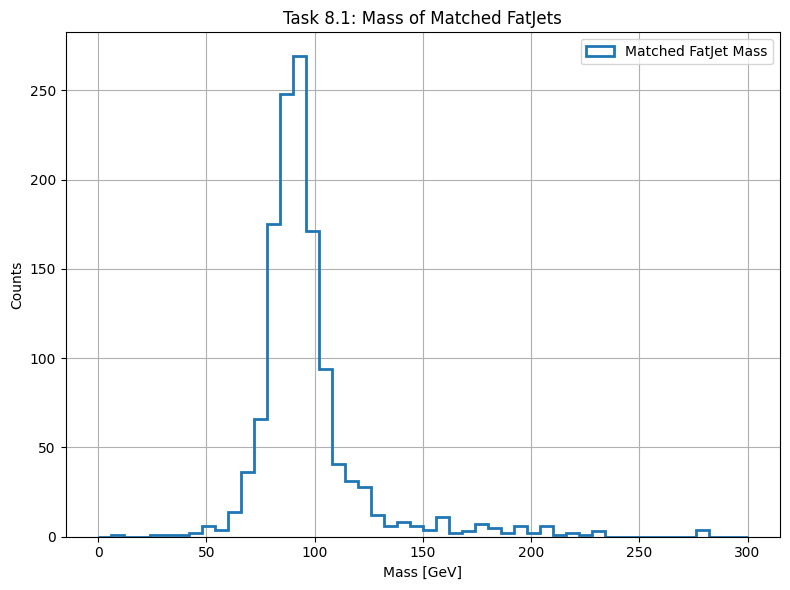

In [11]:
## Task 8.1

# Flatten the matched FatJets and extract their mass
fatjet_masses = ak.flatten(matched_fatjets.mass)

# Plot the mass distribution
plt.figure(figsize=(8, 6))
plt.hist(fatjet_masses, bins=50, range=(0, 300), histtype='step', linewidth=2, label='Matched FatJet Mass')
plt.xlabel("Mass [GeV]")
plt.ylabel("Counts")
plt.title("Task 8.1: Mass of Matched FatJets")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

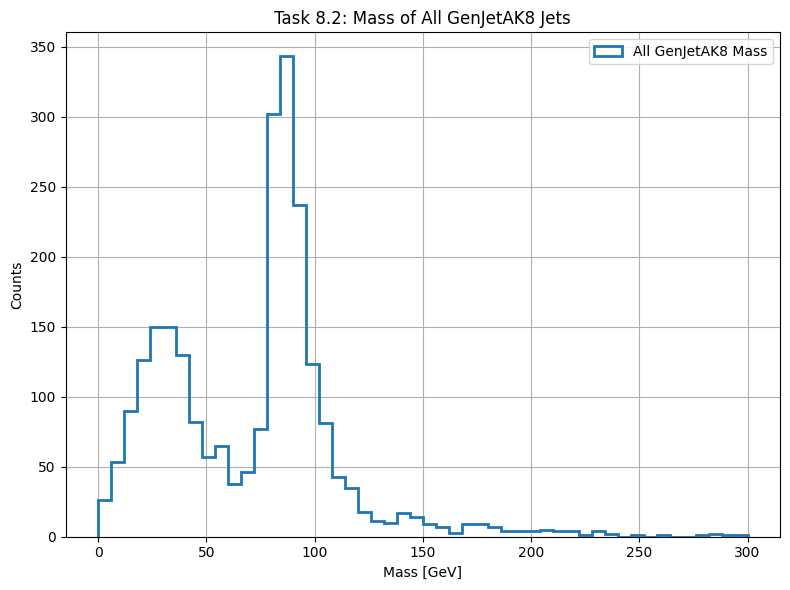

In [12]:
## Task 8.2: Mass of all GenJetAK8 jets

# Create 4-vectors for GenJetAK8 using vector
genjets = vector.zip({
    "pt": events["GenJetAK8_pt"],
    "eta": events["GenJetAK8_eta"],
    "phi": events["GenJetAK8_phi"],
    "mass": events["GenJetAK8_mass"]
})

# Flatten the mass values across events
genjet_masses = ak.flatten(genjets.mass)

# Plot the mass distribution
plt.figure(figsize=(8, 6))
plt.hist(genjet_masses, bins=50, range=(0, 300), histtype='step', linewidth=2, label='All GenJetAK8 Mass')
plt.xlabel("Mass [GeV]")
plt.ylabel("Counts")
plt.title("Task 8.2: Mass of All GenJetAK8 Jets")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

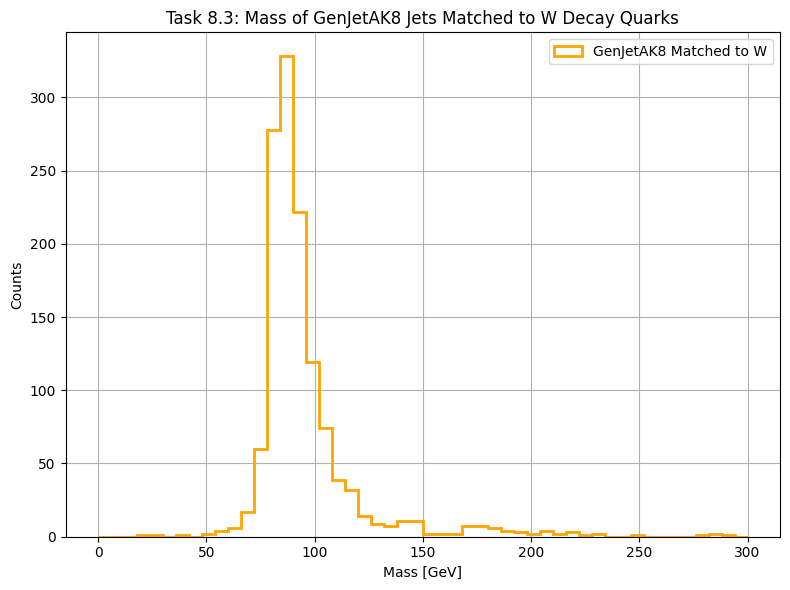

In [13]:
## Task 8.3 -- Mass of GenJetAK8 jets matched to a W boson

# Step 1: Use the same matching logic as match_w_to_fatjets to find GenJetAK8 jets within ΔR < 0.8 of both W decay quarks
def get_matched_genjets_from_w(events, w_quark_map):
    matched_genjet_pts = []
    matched_genjet_etas = []
    matched_genjet_phis = []
    matched_genjet_masses = []

    # Build GenJetAK8 and GenPart as 4-vectors
    genjets = vector.zip({
        "pt": events["GenJetAK8_pt"],
        "eta": events["GenJetAK8_eta"],
        "phi": events["GenJetAK8_phi"],
        "mass": events["GenJetAK8_mass"]
    })

    genparts = vector.zip({
        "pt": events["GenPart_pt"],
        "eta": events["GenPart_eta"],
        "phi": events["GenPart_phi"],
        "mass": events["GenPart_mass"]
    })

    for (evt_idx, w_gen_idx), quark_gen_indices in w_quark_map.items():
        q1 = genparts[evt_idx][quark_gen_indices[0]]
        q2 = genparts[evt_idx][quark_gen_indices[1]]

        for gj in genjets[evt_idx]:
            if gj.deltaR(q1) < 0.8 and gj.deltaR(q2) < 0.8:
                matched_genjet_pts.append(gj.pt)
                matched_genjet_etas.append(gj.eta)
                matched_genjet_phis.append(gj.phi)
                matched_genjet_masses.append(gj.mass)
                break  # only one match per W

    # Return vector-aware array so we can access .mass etc.
    return vector.zip({
        "pt": ak.Array(matched_genjet_pts),
        "eta": ak.Array(matched_genjet_etas),
        "phi": ak.Array(matched_genjet_phis),
        "mass": ak.Array(matched_genjet_masses),
    })

# Step 2: Match GenJets to W decays and extract their masses
matched_genjets = get_matched_genjets_from_w(events, w_quark_map)
matched_genjet_masses = ak.to_numpy(matched_genjets.mass)

# Step 3: Plot the distribution
plt.figure(figsize=(8, 6))
plt.hist(matched_genjet_masses, bins=50, range=(0, 300), histtype='step', linewidth=2, color='orange', label='GenJetAK8 Matched to W')
plt.xlabel("Mass [GeV]")
plt.ylabel("Counts")
plt.title("Task 8.3: Mass of GenJetAK8 Jets Matched to W Decay Quarks")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

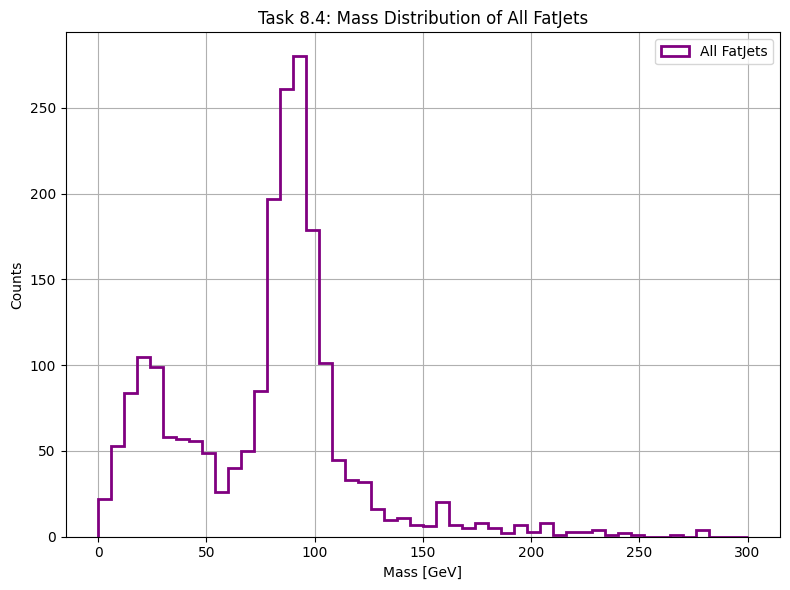

In [14]:
## Task 8.4 -- Mass of all FatJets (no matching to W required)

# Step 1: Extract all FatJet masses (flatten in case it's jagged)
all_fatjet_masses = ak.to_numpy(ak.flatten(events["FatJet_mass"]))

# Step 2: Plot
plt.figure(figsize=(8, 6))
plt.hist(all_fatjet_masses, bins=50, range=(0, 300), histtype='step', linewidth=2, color='purple', label='All FatJets')
plt.xlabel("Mass [GeV]")
plt.ylabel("Counts")
plt.title("Task 8.4: Mass Distribution of All FatJets")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


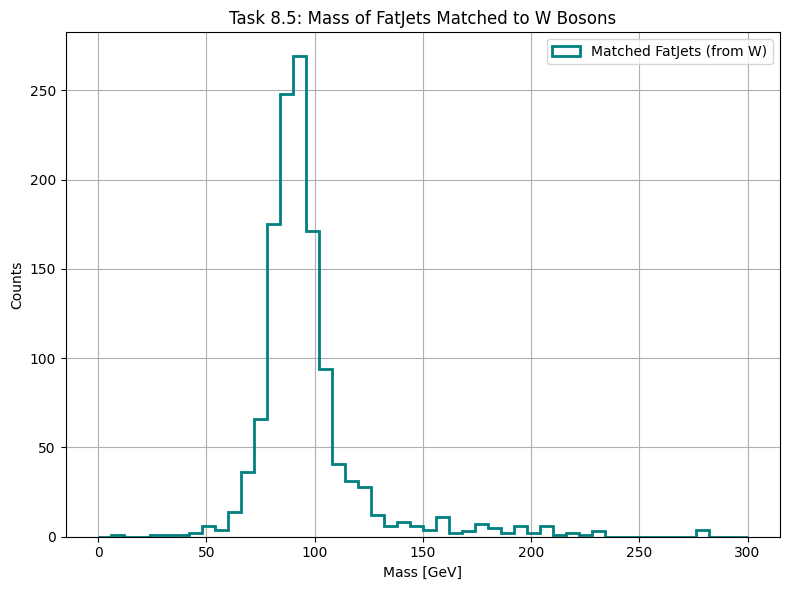

In [15]:
## Task 8.5 -- Mass of FatJets matched to W decay quarks

# Step 1: Ensure matched_fatjets is defined
# (you should have already run this earlier)
# matched_fatjets = match_w_to_fatjets(events, w_quark_map)

# Step 2: Extract and flatten the mass values
matched_fatjet_masses = ak.to_numpy(ak.flatten(matched_fatjets.mass))

# Step 3: Plot
plt.figure(figsize=(8, 6))
plt.hist(matched_fatjet_masses, bins=50, range=(0, 300), histtype='step', linewidth=2, color='teal', label='Matched FatJets (from W)')
plt.xlabel("Mass [GeV]")
plt.ylabel("Counts")
plt.title("Task 8.5: Mass of FatJets Matched to W Bosons")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


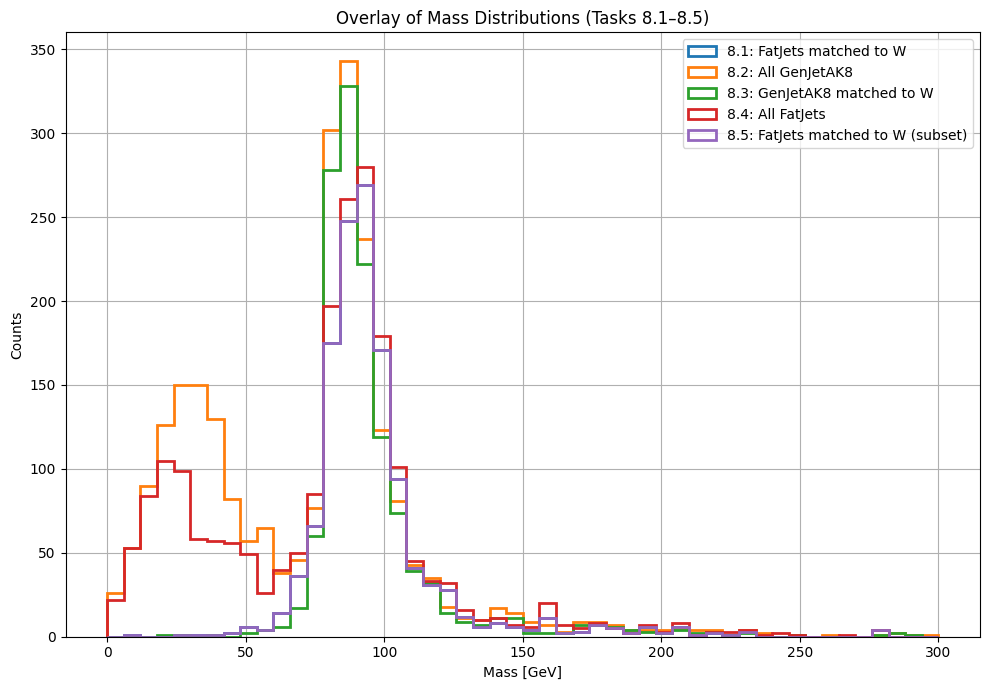

In [16]:
## Task 8: all plots 

plt.figure(figsize=(10, 7))

# Task 8.1: Matched FatJets
fatjet_masses = ak.to_numpy(ak.flatten(matched_fatjets.mass))
plt.hist(fatjet_masses, bins=50, range=(0, 300), histtype='step', linewidth=2,
         label="8.1: FatJets matched to W")

# Task 8.2: All GenJetAK8
genjet_masses = ak.to_numpy(ak.flatten(events["GenJetAK8_mass"]))
plt.hist(genjet_masses, bins=50, range=(0, 300), histtype='step', linewidth=2,
         label="8.2: All GenJetAK8")

# Task 8.3: GenJetAK8 matched to W
matched_genjets = get_matched_genjets_from_w(events, w_quark_map)
matched_genjet_masses = ak.to_numpy([j.mass for j in matched_genjets])
plt.hist(matched_genjet_masses, bins=50, range=(0, 300), histtype='step', linewidth=2,
         label="8.3: GenJetAK8 matched to W")

# Task 8.4: All FatJets
all_fatjet_masses = ak.to_numpy(ak.flatten(events["FatJet_mass"]))
plt.hist(all_fatjet_masses, bins=50, range=(0, 300), histtype='step', linewidth=2,
         label="8.4: All FatJets")

# Task 8.5: FatJets matched to W
matched_fatjet_masses = ak.to_numpy(ak.flatten(matched_fatjets.mass))
plt.hist(matched_fatjet_masses, bins=50, range=(0, 300), histtype='step', linewidth=2,
         label="8.5: FatJets matched to W (subset)")

# Formatting
plt.xlabel("Mass [GeV]")
plt.ylabel("Counts")
plt.title("Overlay of Mass Distributions (Tasks 8.1–8.5)")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()

### TASK 9:

For the FatJets (or the FatJets coming from a W) let's plot also some variables that are commonly used to distinguish Jets coming from a W (or Z boson) from the background. Remind me to give you some material to learn about jet tagging when you get here!
1. Compare the mass and the soft drop mass ( `msoftdrop`)
2. Plot also the N-subjettines variables `tau1`, `tau2` and their ratio

In [17]:
# Task 9
## define the dataset
## extract properties of FatJets matched to W
matched_fatjet_mass       = ak.to_numpy(ak.flatten(matched_fatjets.mass))
matched_fatjet_msoftdrop  = ak.to_numpy(ak.flatten(matched_fatjets.msoftdrop))
matched_fatjet_tau1       = ak.to_numpy(ak.flatten(matched_fatjets.tau1))
matched_fatjet_tau2       = ak.to_numpy(ak.flatten(matched_fatjets.tau2))

# avoid divide-by-zero by masking invalid tau1 values
valid_tau_mask = matched_fatjet_tau1 > 0
tau21 = matched_fatjet_tau2[valid_tau_mask] / matched_fatjet_tau1[valid_tau_mask]

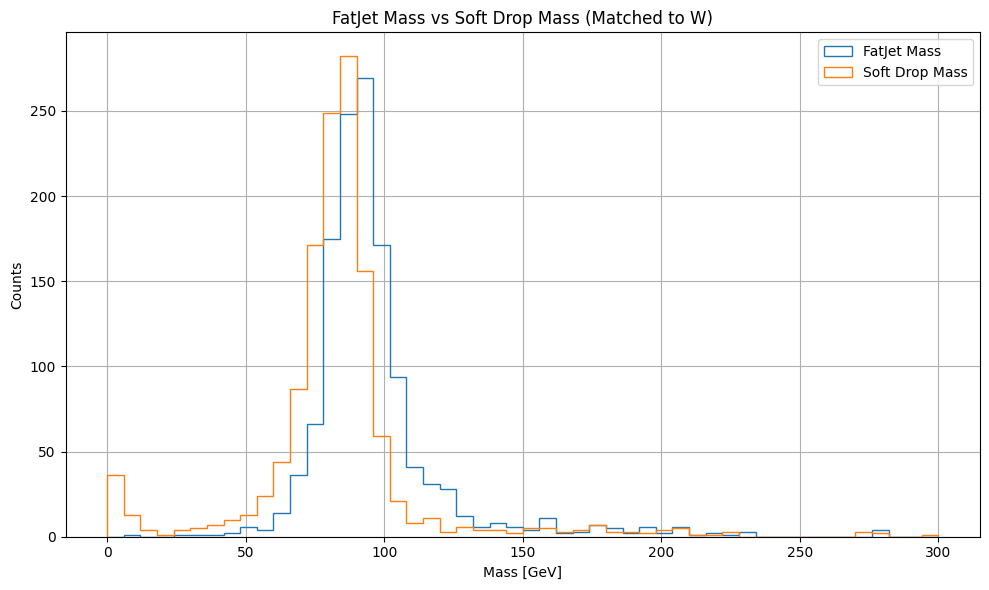

In [18]:
## compare FatJet mass vs Soft Drop mass
plt.figure(figsize=(10, 6))
plt.hist(matched_fatjet_mass, bins=50, range=(0, 300), histtype='step', label="FatJet Mass")
plt.hist(matched_fatjet_msoftdrop, bins=50, range=(0, 300), histtype='step', label="Soft Drop Mass")
plt.xlabel("Mass [GeV]")
plt.ylabel("Counts")
plt.title("FatJet Mass vs Soft Drop Mass (Matched to W)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

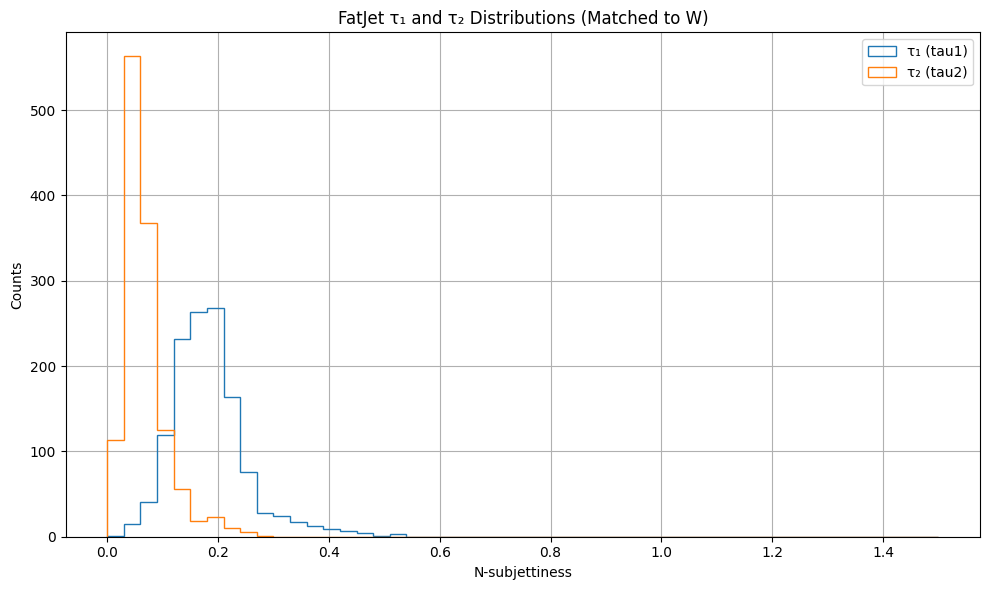

In [19]:
## N-subjettiness: T1 and T2 

plt.figure(figsize=(10, 6))
plt.hist(matched_fatjet_tau1, bins=50, range=(0, 1.5), histtype='step', label="τ₁ (tau1)")
plt.hist(matched_fatjet_tau2, bins=50, range=(0, 1.5), histtype='step', label="τ₂ (tau2)")
plt.xlabel("N-subjettiness")
plt.ylabel("Counts")
plt.title("FatJet τ₁ and τ₂ Distributions (Matched to W)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

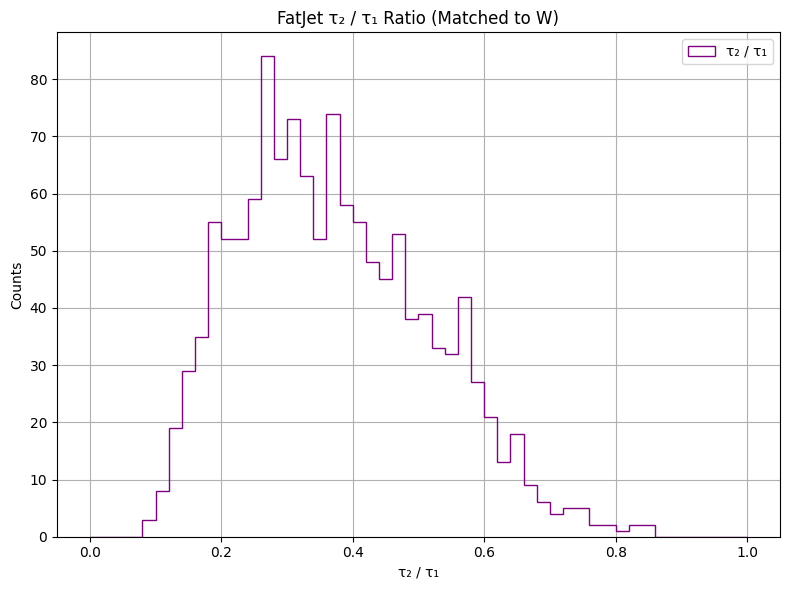

In [20]:
## N-sibjettiness ratio: T2/T1

plt.figure(figsize=(8, 6))
plt.hist(tau21, bins=50, range=(0, 1), histtype='step', color='purple', label="τ₂ / τ₁")
plt.xlabel("τ₂ / τ₁")
plt.ylabel("Counts")
plt.title("FatJet τ₂ / τ₁ Ratio (Matched to W)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### TASK 10:

Identify the subjets of the FatJets coming from the W and plot their kinematic variables

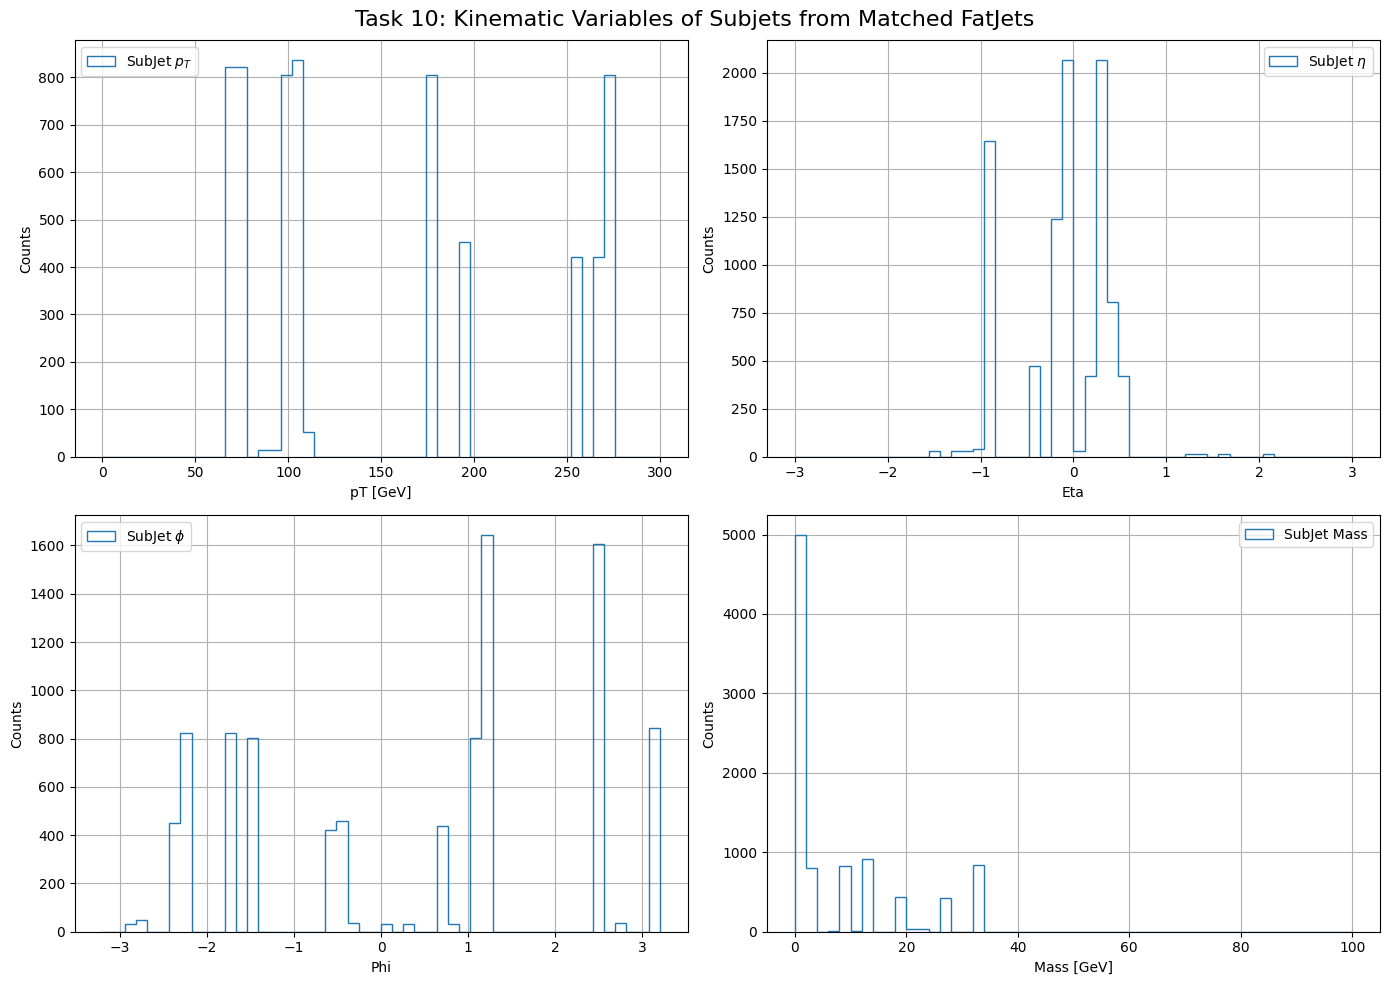

In [25]:
# Task 10: Plot kinematics of subjets from matched FatJets

# Step 1: Extract subjet indices
subjet1_indices = ak.flatten(matched_fatjets.subJetIdx1)
subjet2_indices = ak.flatten(matched_fatjets.subJetIdx2)

# Step 2: Load all subjets from the event
all_subjets = ak.zip({
    "pt": events["SubJet_pt"],
    "eta": events["SubJet_eta"],
    "phi": events["SubJet_phi"],
    "mass": events["SubJet_mass"]
}, with_name="Momentum4D")

# Step 3: Get valid subjets by index
subjets1 = all_subjets[subjet1_indices]
subjets2 = all_subjets[subjet2_indices]

# Step 4: Combine both sets of subjets
all_matched_subjets = ak.concatenate([subjets1, subjets2], axis=0)

# Step 5: Plot distributions
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.hist(ak.to_numpy(ak.flatten(all_matched_subjets.pt)), bins=50, range=(0, 300), histtype='step', label='SubJet $p_T$')
plt.xlabel("pT [GeV]"); plt.ylabel("Counts"); plt.grid(True); plt.legend()

plt.subplot(2, 2, 2)
plt.hist(ak.to_numpy(ak.flatten(all_matched_subjets.eta)), bins=50, range=(-3, 3), histtype='step', label='SubJet $\eta$')
plt.xlabel("Eta"); plt.ylabel("Counts"); plt.grid(True); plt.legend()

plt.subplot(2, 2, 3)
plt.hist(ak.to_numpy(ak.flatten(all_matched_subjets.phi)), bins=50, range=(-3.2, 3.2), histtype='step', label='SubJet $\phi$')
plt.xlabel("Phi"); plt.ylabel("Counts"); plt.grid(True); plt.legend()

plt.subplot(2, 2, 4)
plt.hist(ak.to_numpy(ak.flatten(all_matched_subjets.mass)), bins=50, range=(0, 100), histtype='step', label='SubJet Mass')
plt.xlabel("Mass [GeV]"); plt.ylabel("Counts"); plt.grid(True); plt.legend()

plt.suptitle("Task 10: Kinematic Variables of Subjets from Matched FatJets", fontsize=16)
plt.tight_layout()
plt.show()

### TASK 11:

Can you calculate cos theta for the jets and subjets instead of the gen particles? This may be tricky!! Take your time!

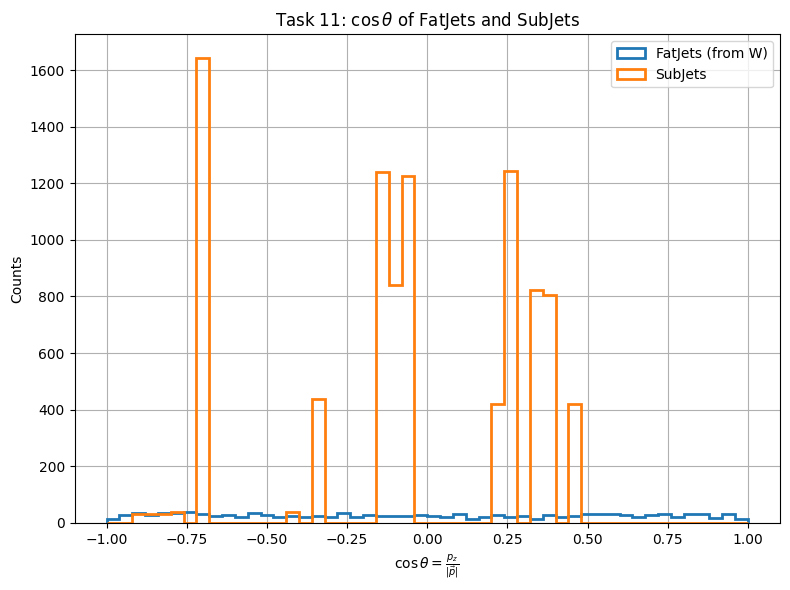

In [32]:
## Task 11 – cos(theta) for FatJets and their Subjets

# --- Step 1: Create vector objects for matched FatJets ---
matched_fatjets_vec = vector.zip({
    "pt": matched_fatjets.pt,
    "eta": matched_fatjets.eta,
    "phi": matched_fatjets.phi,
    "mass": matched_fatjets.mass
})

# --- Step 2: Compute cos(theta) for FatJets: cosθ = pz / |p| ---
fatjet_pz = ak.ravel(matched_fatjets_vec.pz)
fatjet_px = ak.ravel(matched_fatjets_vec.px)
fatjet_py = ak.ravel(matched_fatjets_vec.py)
fatjet_p = np.sqrt(fatjet_px**2 + fatjet_py**2 + fatjet_pz**2)
cos_theta_fatjets = fatjet_pz / fatjet_p

# --- Step 3: Get subjet indices from matched FatJets ---
subjet1_idx = ak.ravel(matched_fatjets.subJetIdx1)
subjet2_idx = ak.ravel(matched_fatjets.subJetIdx2)

# --- Step 4: Filter out invalid indices (e.g., -1) ---
valid1_mask = subjet1_idx >= 0
valid2_mask = subjet2_idx >= 0

# --- Step 5: Gather all subjets into a vector array ---
all_subjets_raw = vector.zip({
    "pt": events["SubJet_pt"],
    "eta": events["SubJet_eta"],
    "phi": events["SubJet_phi"],
    "mass": events["SubJet_mass"]
})

# --- Step 6: Extract valid subjets by index ---
subjets1_raw = all_subjets_raw[subjet1_idx[valid1_mask]]
subjets2_raw = all_subjets_raw[subjet2_idx[valid2_mask]]

# --- Step 7: Re-wrap these extracted subjets with vector.zip (critical step!) ---
subjets1 = vector.zip({
    "pt": subjets1_raw.pt,
    "eta": subjets1_raw.eta,
    "phi": subjets1_raw.phi,
    "mass": subjets1_raw.mass
})

subjets2 = vector.zip({
    "pt": subjets2_raw.pt,
    "eta": subjets2_raw.eta,
    "phi": subjets2_raw.phi,
    "mass": subjets2_raw.mass
})

# --- Step 8: Define a helper function to compute cos(theta) = pz / |p| ---
def compute_cos_theta(vec_array):
    pz = vec_array.pz
    p = np.sqrt(vec_array.px**2 + vec_array.py**2 + vec_array.pz**2)
    return ak.flatten(pz / p)

# --- Step 9: Compute cos(theta) for subjets individually ---
cos_theta_subjet1 = compute_cos_theta(subjets1)
cos_theta_subjet2 = compute_cos_theta(subjets2)

# --- Step 10: Combine subjet results ---
cos_theta_subjets = np.concatenate([cos_theta_subjet1, cos_theta_subjet2])

# --- Step 11: Plot results ---
plt.figure(figsize=(8, 6))
plt.hist(cos_theta_fatjets, bins=50, range=(-1, 1), histtype='step', linewidth=2, label='FatJets (from W)')
plt.hist(cos_theta_subjets, bins=50, range=(-1, 1), histtype='step', linewidth=2, label='SubJets')
plt.xlabel(r"$\cos\theta = \frac{p_z}{|\vec{p}|}$")
plt.ylabel("Counts")
plt.title("Task 11: $\cos\\theta$ of FatJets and SubJets")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### How would I split the signal and background
    1. Signal jets/subjets are: 
    - FatJets or GenJetAK8 that are within ΔR < 0.8 of both W daughter quarks
    - or whose subjets came from matched FatJets 
    
    2. Background jets/subjets are 
    - the remaining jets/subjets that fail the signal-matching criteria
    
    Side Note: In real analyses, i'd label jets as signal/background using truth matching to GenParticles or using MC truth labels (like parton flavor or hadron ancestry). But this ΔR-matching method is a good approximation for generator-level studies.

In [34]:
# # Step 1: All FatJets in all events
# all_fatjets = vector.zip({
#     "pt": events["FatJet_pt"],
#     "eta": events["FatJet_eta"],
#     "phi": events["FatJet_phi"],
#     "mass": events["FatJet_mass"]
# })

# # Step 2: Find which FatJets are matched (i.e. signal jets)
# # Flattening both matched and all fatjets for comparison
# matched_fatjets_flat = ak.flatten(matched_fatjets)
# all_fatjets_flat = ak.flatten(all_fatjets)

# # Step 3: Background = all_fatjets - matched_fatjets
# # Use stringified pt/eta/phi/mass to match objects (approximate trick)
# def stringify(vec):  # crude but effective matching workaround
#     return ak.flatten(ak.zip({
#         "pt": vec.pt,
#         "eta": vec.eta,
#         "phi": vec.phi,
#         "mass": vec.mass
#     }).to_list())

# matched_keys = set(tuple(x) for x in stringify(matched_fatjets_flat))
# background_fatjets = [jet for jet in all_fatjets_flat if tuple(jet.to_list()) not in matched_keys]
# background_fatjets = ak.Array(background_fatjets)